In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

In [80]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [81]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [82]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [83]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [85]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [86]:
df.duplicated().sum()

np.int64(0)

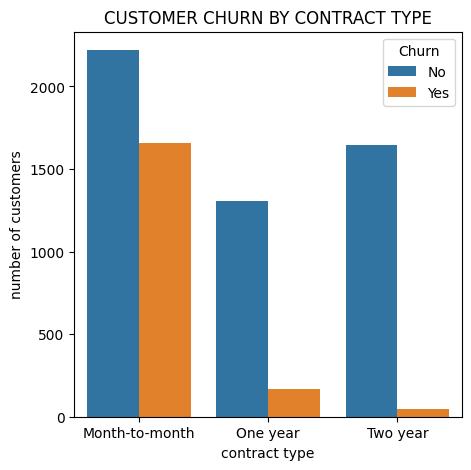

In [87]:
import matplotlib.pyplot as plt
plt.figure(figsize = (5,5))
sns.countplot(
    data = df,x= 'Contract',hue = 'Churn'
)
plt.title("CUSTOMER CHURN BY CONTRACT TYPE")
plt.xlabel("contract type")
plt.ylabel("number of customers")
plt.show()

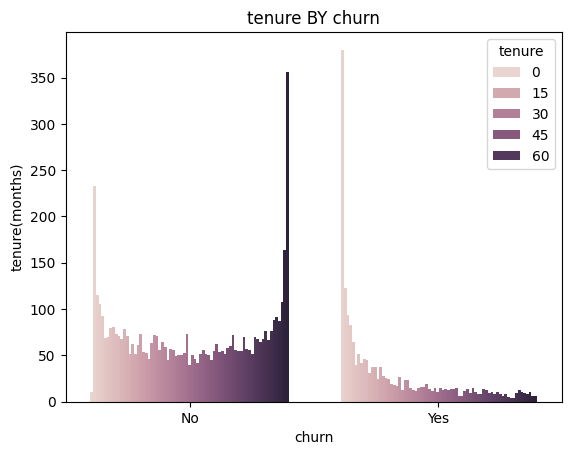

In [88]:
import matplotlib.pyplot as plt
sns.countplot(
    data = df,x= 'Churn',hue = 'tenure'
)
plt.title("tenure BY churn")
plt.xlabel("churn")
plt.ylabel("tenure(months)")
plt.show()

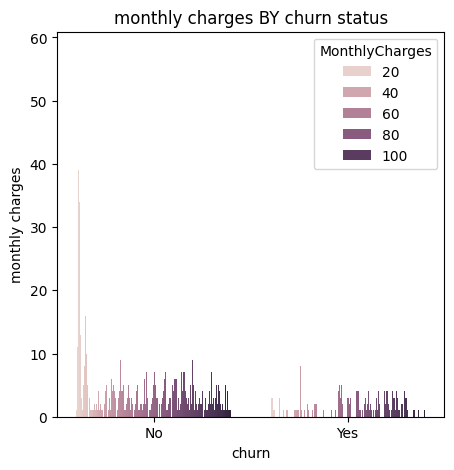

In [89]:
import matplotlib.pyplot as plt
plt.figure(figsize = (5,5))
sns.countplot(
    data = df,x= 'Churn',hue = 'MonthlyCharges'
)
plt.title("monthly charges BY churn status")
plt.xlabel("churn")
plt.ylabel("monthly charges")
plt.show()

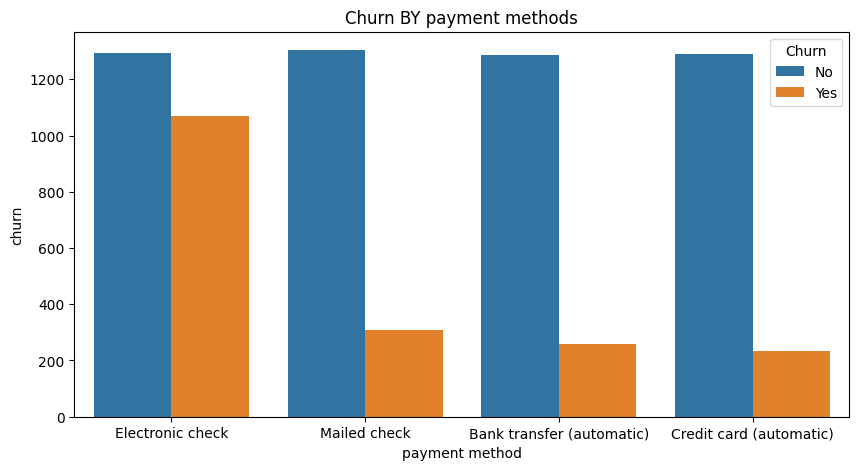

In [90]:
plt.figure(figsize = (10,5))
sns.countplot(
    data = df,x= 'PaymentMethod',hue = 'Churn'
)
plt.title( "Churn BY payment methods")
plt.xlabel("payment method")
plt.ylabel("churn")
plt.show()

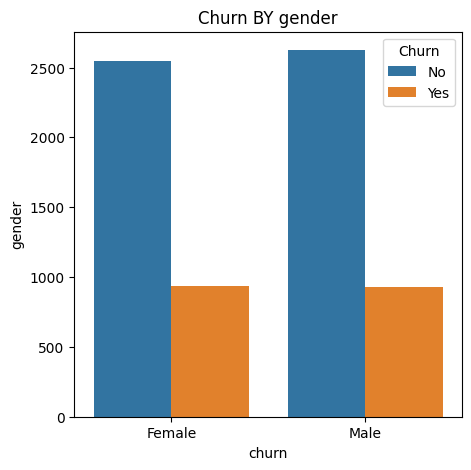

In [91]:
plt.figure(figsize = (5,5))
sns.countplot(
    data = df,x= 'gender',hue = 'Churn'
)
plt.title( "Churn BY gender")
plt.xlabel("churn")
plt.ylabel("gender")
plt.show()

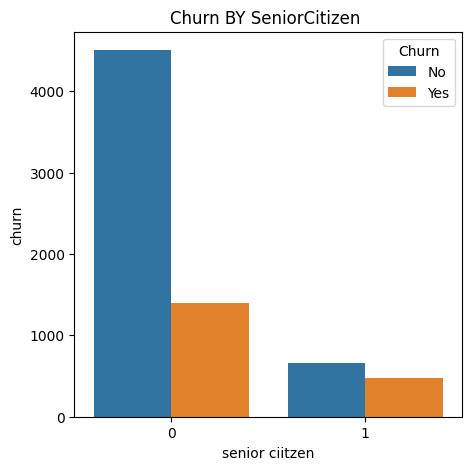

In [92]:
plt.figure(figsize = (5,5))
sns.countplot(
    data = df,x= 'SeniorCitizen',hue = 'Churn'
)
plt.title( "Churn BY SeniorCitizen ")
plt.xlabel("senior ciitzen")
plt.ylabel("churn")
plt.show()

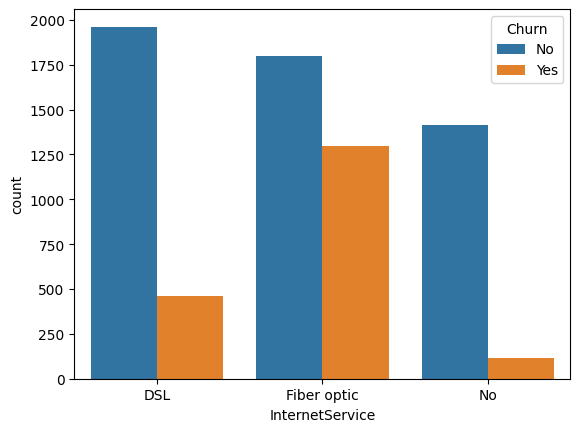

In [93]:
sns.countplot(
    data = df,x = 'InternetService',hue= "Churn"
)
plt.show()

In [94]:
df["TotalCharges"]= pd.to_numeric(
    df["TotalCharges"],errors = "coerce"
)

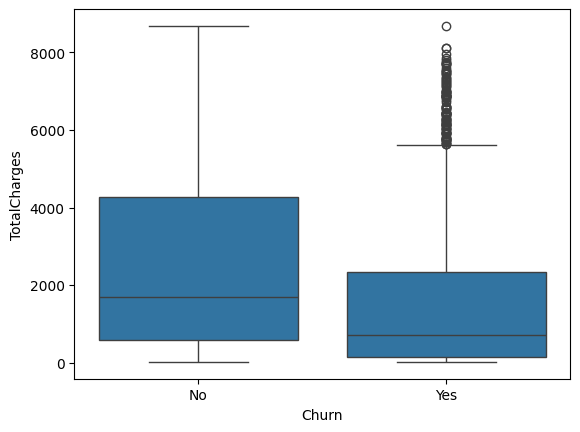

In [95]:
sns.boxplot(
    data = df,x = "Churn", y = "TotalCharges"
)
plt.show()

In [96]:
df["avg_monthly_value"]= df["TotalCharges"]/df["tenure"]

In [97]:
def define_spender_type(charge):
    if charge > 80:
        return "high"
    elif charge > 40:
        return "medium"
    else :
        return "low"
df['spender_type'] = df['MonthlyCharges'].apply(define_spender_type)

In [98]:
df["longTermCustomer"] = (df["tenure"]<12).astype(int)

In [99]:
df["HighMonthlyCharge"]=(df["MonthlyCharges"]>80).astype(int)

In [100]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [101]:
# Re-align y with the cleaned X, then re-split the data
y = y.loc[X.index]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)

In [102]:
X

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,avg_monthly_value,spender_type,longTermCustomer,HighMonthlyCharge
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,29.850000,low,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,55.573529,medium,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,54.075000,medium,1,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,40.905556,medium,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,75.825000,medium,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.50,82.937500,high,0,1
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,102.262500,high,0,1
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,31.495455,low,1,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Mailed check,74.40,306.60,76.650000,medium,1,0


In [103]:
# Drop rows with NaN values from X
X = X.dropna()
# Drop rows with infinity values from X (e.g., from division by zero)
X = X[~X.isin([np.inf, -np.inf]).any(axis=1)]

In [104]:
y = y.map({"No" :0,"Yes":1})

In [105]:
X= pd.get_dummies(
    X,
    drop_first = True
)

In [106]:
# Re-initialize X and y from the original DataFrame
X = df.drop('Churn', axis=1)
y = df['Churn']

# Map 'Churn' values to numerical (0 and 1)
y = y.map({"No": 0, "Yes": 1})

# Apply one-hot encoding to all categorical features in X
X = pd.get_dummies(X, drop_first=True)

# Ensure 'TotalCharges' is numeric (already done in earlier cells, but safe to ensure)
# The 'TotalCharges' conversion and creation of 'avg_monthly_value', 'spender_type' should ideally be done before get_dummies if they are based on original columns.
# Assuming these are already in df and carried over into X.

# Drop rows with NaN values and infinite values from X
X = X.dropna()
X = X[~X.isin([np.inf, -np.inf]).any(axis=1)]

# Re-align y's index with the cleaned X, as some rows might have been dropped
y = y.loc[X.index]

# Perform train-test split *after* all preprocessing and one-hot encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Identify numerical columns for scaling
# Include 'avg_monthly_value' which was created earlier
num_cols_for_scaling = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_value"]

# Filter to ensure only columns present in X_train are selected for scaling
num_cols_present = [col for col in num_cols_for_scaling if col in X_train.columns]

# Initialize and apply StandardScaler to only the identified numerical columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols_present])
X_test_scaled = scaler.transform(X_test[num_cols_present])

# Create DataFrames for the scaled numerical features, preserving indices
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=num_cols_present, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=num_cols_present, index=X_test.index)

# Drop the original numerical columns from X_train and X_test
X_train_non_num = X_train.drop(columns=num_cols_present)
X_test_non_num = X_test.drop(columns=num_cols_present)

# Concatenate the non-numerical (one-hot encoded) features with the scaled numerical features
X_train = pd.concat([X_train_non_num, X_train_scaled_df], axis=1)
X_test = pd.concat([X_test_non_num, X_test_scaled_df], axis=1)

print("Data preprocessing and splitting complete. X_train and X_test are now ready for model training.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print("X_train dtypes:", X_train.dtypes.unique())


Data preprocessing and splitting complete. X_train and X_test are now ready for model training.
X_train shape: (5625, 7077), X_test shape: (1407, 7077)
X_train dtypes: [dtype('int64') dtype('bool') dtype('float64')]


In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)

In [108]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

In [109]:
baseline_results = {}

In [110]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100,1000],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc'
)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
0.8467850866892871


In [111]:
rf = RandomForestClassifier(random_state=42,
                            n_estimators = 500,
                            max_depth = None,
                            min_samples_split = 2,
                            min_samples_leaf = 1,
                            class_weight="balanced"
                            )

In [112]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=None,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

In [113]:
grid.fit(X_train,y_train)
rf.fit(X_train,y_train)
xgb.fit(X_train,y_train)

KeyboardInterrupt: 

In [ ]:
models = {
    "Logistic Regression": grid.best_estimator_,
    "Random Forest": rf,
    "XGBoost": xgb,
}

In [ ]:
from sklearn.metrics import(
 accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
)

In [ ]:
results=[
    
]

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results.append({
        'Model' : name,
        'precision':precision_score(y_test,y_pred),
        'Recall': recall_score(y_test , y_pred),
        'ROC AUC' : roc_auc_score(y_test , y_prob),
        'Accuracy' : accuracy_score(y_test , y_pred),
        'f1 score':f1_score(y_test,y_pred)
    })

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,precision,Recall,ROC AUC,Accuracy,f1 score
0,Logistic Regression,0.639498,0.545455,0.834940,0.797441,0.588745
1,Random Forest,0.642612,0.500000,0.830095,0.793177,0.562406
2,XGBoost,0.588757,0.532086,0.816596,0.776830,0.558989


In [ ]:
results_df.sort_values(
    by="ROC AUC",
    ascending = False
)

,Model,precision,Recall,ROC AUC,Accuracy,f1 score
0,Logistic Regression,0.639498,0.545455,0.834940,0.797441,0.588745
1,Random Forest,0.642612,0.500000,0.830095,0.793177,0.562406
2,XGBoost,0.588757,0.532086,0.816596,0.776830,0.558989


In [118]:
import joblib
best_model = grid.best_estimator_ 
joblib.dump(best_model,"churn_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    grid.best_estimator_,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores.mean())

0.8457243163164978


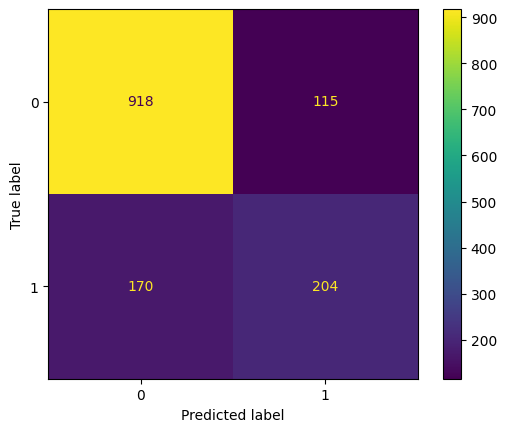

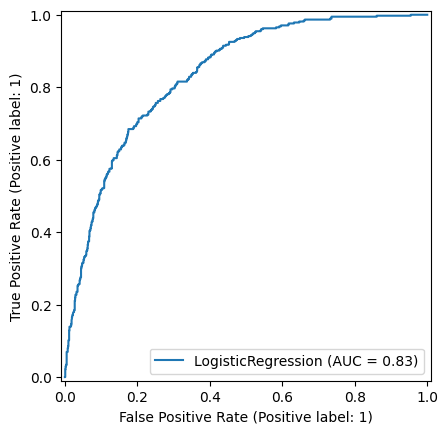

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

ConfusionMatrixDisplay.from_estimator(
    grid.best_estimator_,
    X_test,
    y_test
)

plt.show()

RocCurveDisplay.from_estimator(
    grid.best_estimator_,
    X_test,
    y_test
)

plt.show()

In [114]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [ ]:
import shap

c:\Users\user\OneDrive\Desktop\my python folder\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [115]:
explainer = shap.Explainer(grid.best_estimator_,X_train)

Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


In [116]:
shap_valuues = explainer(X_test)

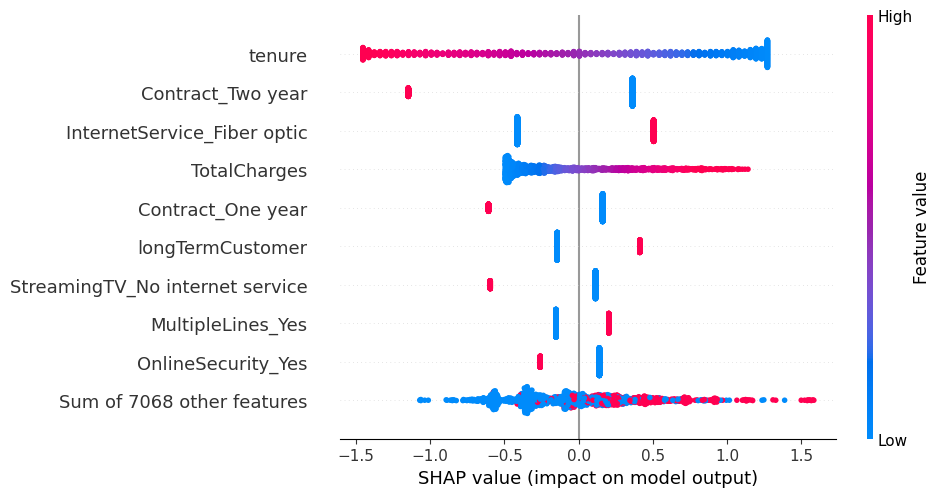

In [117]:
shap.plots.beeswarm(shap_valuues)

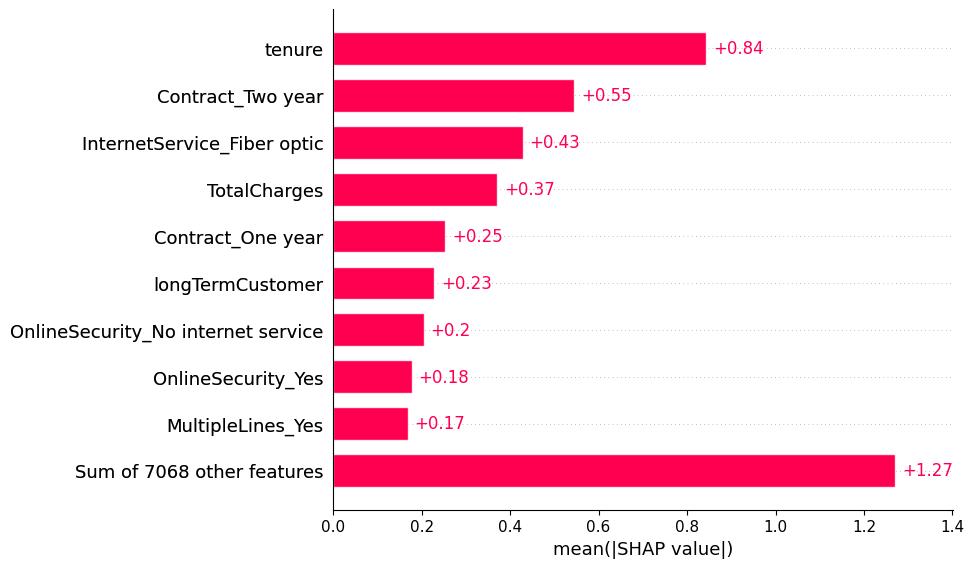

In [77]:
shap.plots.bar(shap_valuues)